# Diffraction Image Analysis Toolkit - VS Code Local Version

This notebook is a local replacement for `Hackathon_14_Diffraction_Structured.ipynb`.
It removes the Google Colab Drive mount and uses the TIFF and CIF files in this workspace.

Open this notebook in VS Code, select a Python kernel, and run the cells from top to bottom.
The first code cell installs the packages needed by the selected kernel.

## 0. Local setup

Run the install cell once for the VS Code kernel you selected. If the packages are already installed, `%pip` will keep the installed versions.

In [ ]:
# Install packages into the currently selected VS Code notebook kernel.
%pip install -q numpy scipy matplotlib tifffile gemmi


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from collections import defaultdict
from itertools import product
from pathlib import Path
import math
import re

import gemmi
import matplotlib.pyplot as plt
import numpy as np
import tifffile
from scipy.ndimage import gaussian_filter, sobel
from scipy.optimize import minimize

## 1. Local file paths

The notebook searches upward from the kernel working directory for the local `Test Tiffs` folder.
Change `WAFER_SAMPLE` to `Nb`, `Ti`, or `Blank` before loading the wafer image.

In [ ]:
def find_workspace_root(start):
    start = Path(start).resolve()
    candidates = (start, *start.parents)
    for candidate in candidates:
        if (candidate / "Test Tiffs").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the local 'Test Tiffs' folder. Open this notebook from the Day 14 workspace."
    )


WORKSPACE_ROOT = find_workspace_root(Path.cwd())
TEST_TIFFS = WORKSPACE_ROOT / "Test Tiffs"
POWDER_IMAGE = TEST_TIFFS / "Stitched Images" / "xrd_JS06_20260323-162040_b9dead_sum.tiff"
WAFER_IMAGES = {
    "Blank": TEST_TIFFS / "Wafer Images" / "Blank.tiff",
    "Nb": TEST_TIFFS / "Wafer Images" / "Nb.tiff",
    "Ti": TEST_TIFFS / "Wafer Images" / "Ti.tiff",
}
CIF_FILE = TEST_TIFFS / "film.cif"

# Detector and experiment settings from the original notebook.
PIXEL_SIZE_MM = 0.172
WAVELENGTH_ANGSTROM = 0.1665
CAMERA_LENGTH_MM = 1054.0
WAFER_SAMPLE = "Nb"

required_files = [POWDER_IMAGE, CIF_FILE, *WAFER_IMAGES.values()]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError("Missing local inputs:\n" + "\n".join(map(str, missing_files)))

print("Workspace root:", WORKSPACE_ROOT)
print("Powder image  :", POWDER_IMAGE.name)
print("Wafer image   :", WAFER_IMAGES[WAFER_SAMPLE].name)
print("CIF file      :", CIF_FILE.name)

Workspace root: /Users/nannorymunireach/Library/CloudStorage/GoogleDrive-nmunirea@vols.utk.edu/My Drive/Hackathon IRG2/Day 14
Powder image  : xrd_JS06_20260323-162040_b9dead_sum.tiff
Wafer image   : Nb.tiff
CIF file      : film.cif


## 2. TIFF loading, center finding, and ring overlay helpers

In [ ]:
def load_and_view_tiff(
    path,
    cmap="inferno",
    percentile_low=1,
    percentile_high=99.5,
    log_scale=True,
    figsize=(8, 8),
    show_plot=True,
):
    """Load a 2D TIFF, create per-pixel datasets, and scale it for display."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"TIFF not found: {path}")

    image_array = tifffile.imread(path)
    if image_array.ndim != 2:
        raise ValueError(f"Expected a 2D TIFF, got shape {image_array.shape} from {path.name}")

    image = image_array.astype(np.float64)
    finite_mask = np.isfinite(image)
    if not np.any(finite_mask):
        raise ValueError(f"{path.name} contains no finite pixels")

    valid_pixels = image[finite_mask]
    vmin = np.percentile(valid_pixels, percentile_low)
    vmax = np.percentile(valid_pixels, percentile_high)
    if vmax <= vmin:
        vmax = vmin + 1e-9

    clipped = np.clip(image, vmin, vmax) - vmin
    if log_scale:
        clipped = np.log1p(clipped)

    finite_clipped = clipped[np.isfinite(clipped)]
    cmin = finite_clipped.min()
    cmax = finite_clipped.max()
    if cmax <= cmin:
        display_image = np.zeros_like(clipped, dtype=np.float64)
    else:
        display_image = (clipped - cmin) / (cmax - cmin)
    display_image = np.nan_to_num(display_image, nan=0, posinf=1, neginf=0)

    height, width = image.shape
    y_positions, x_positions = np.indices((height, width))
    raw_dataset = np.column_stack((x_positions.ravel(), y_positions.ravel(), image.ravel()))
    scaled_dataset = np.column_stack(
        (x_positions.ravel(), y_positions.ravel(), display_image.ravel())
    )

    if show_plot:
        plt.figure(figsize=figsize)
        plt.imshow(display_image, cmap=cmap, origin="lower")
        plt.colorbar(label="Scaled Intensity")
        plt.title(f"{path.name}\nDisplay Range: [{vmin:.3g}, {vmax:.3g}]")
        plt.tight_layout()
        plt.show()

    return image_array, raw_dataset, scaled_dataset, display_image

In [ ]:
def find_diffraction_center_fast(
    display_image,
    blur_sigma=2,
    intensity_percentile=92,
    radial_bins=500,
    show_plot=True,
    figsize=(9, 9),
):
    """Find a ring center by maximizing radial histogram sharpness."""
    image = np.nan_to_num(np.asarray(display_image, dtype=np.float64), nan=0)
    smoothed = gaussian_filter(image, sigma=blur_sigma)
    positive_pixels = smoothed[smoothed > 0]
    if positive_pixels.size == 0:
        raise ValueError("Center finding needs nonzero image intensity")

    threshold = np.percentile(positive_pixels, intensity_percentile)
    mask = smoothed >= threshold
    y_points, x_points = np.nonzero(mask)
    weights = smoothed[mask]
    x0 = np.average(x_points, weights=weights)
    y0 = np.average(y_points, weights=weights)

    def radial_sharpness_metric(center):
        xc, yc = center
        radii = np.sqrt((x_points - xc) ** 2 + (y_points - yc) ** 2)
        hist, _ = np.histogram(radii, bins=radial_bins, weights=weights)
        return -np.sum(hist ** 2)

    result = minimize(radial_sharpness_metric, x0=[x0, y0], method="Nelder-Mead")
    center_x, center_y = result.x

    if show_plot:
        plt.figure(figsize=figsize)
        plt.imshow(display_image, cmap="inferno", origin="lower")
        plt.scatter(center_x, center_y, s=250, marker="x", color="cyan")
        plt.title(f"Optimized Diffraction Center\nx={center_x:.2f}, y={center_y:.2f}")
        plt.colorbar(label="Scaled Intensity")
        plt.tight_layout()
        plt.show()

    return center_x, center_y

In [ ]:
def find_diffraction_center_voting(
    display_image,
    blur_sigma=2,
    edge_percentile=94,
    line_length=200,
    show_plot=True,
):
    """Find a diffraction center by radial symmetry voting. This can take minutes."""
    image = np.nan_to_num(np.asarray(display_image, dtype=np.float64), nan=0)
    smoothed = gaussian_filter(image, sigma=blur_sigma)
    gx = sobel(smoothed, axis=1)
    gy = sobel(smoothed, axis=0)
    grad_mag = np.sqrt(gx ** 2 + gy ** 2)
    positive_edges = grad_mag[grad_mag > 0]
    if positive_edges.size == 0:
        raise ValueError("Center finding needs nonzero image gradients")

    threshold = np.percentile(positive_edges, edge_percentile)
    y_points, x_points = np.nonzero(grad_mag >= threshold)
    accumulator = np.zeros_like(image, dtype=np.float64)
    height, width = image.shape

    for y, x in zip(y_points, x_points):
        gxn, gyn = gx[y, x], gy[y, x]
        norm = np.sqrt(gxn ** 2 + gyn ** 2)
        if norm == 0:
            continue
        gxn, gyn = gxn / norm, gyn / norm
        for sign in (+1, -1):
            dx, dy = sign * gxn, sign * gyn
            for radius in range(line_length):
                xx = int(round(x + dx * radius))
                yy = int(round(y + dy * radius))
                if xx < 0 or xx >= width or yy < 0 or yy >= height:
                    break
                accumulator[yy, xx] += 1

    center_y, center_x = np.unravel_index(np.argmax(accumulator), accumulator.shape)

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        axes[0].imshow(display_image, cmap="inferno", origin="lower")
        axes[0].scatter(center_x, center_y, s=300, marker="x", color="cyan")
        axes[0].set_title(f"Detected Center\nx={center_x}, y={center_y}")
        axes[1].imshow(accumulator, cmap="viridis", origin="lower")
        axes[1].scatter(center_x, center_y, s=300, marker="x", color="red")
        axes[1].set_title("Radial Symmetry Accumulator")
        plt.tight_layout()
        plt.show()

    return center_x, center_y, accumulator

In [ ]:
def overlay_diffraction_rings(
    image,
    center,
    radii_pixels,
    cmap="inferno",
    figsize=(9, 9),
    ring_color="cyan",
    ring_width=1.5,
    show_center=True,
):
    """Draw circular diffraction radii around a detector center."""
    center_x, center_y = center
    theta = np.linspace(0, 2 * np.pi, 1000)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image, cmap=cmap, origin="lower")
    for radius in radii_pixels:
        ax.plot(
            center_x + radius * np.cos(theta),
            center_y + radius * np.sin(theta),
            color=ring_color,
            linewidth=ring_width,
        )
    if show_center:
        ax.scatter(center_x, center_y, color="red", s=120, marker="x")
    ax.set_title("Diffraction Rings Overlay")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    return fig, ax

## 3. Find the beam center from the powder image

The fast center finder is used by default. Set `CENTER_METHOD = "voting"` for the slower gradient-voting method from the original notebook.

In [ ]:
powder_image, powder_raw_data, powder_scaled_data, powder_display_image = load_and_view_tiff(
    POWDER_IMAGE,
    percentile_low=1,
    percentile_high=99.9,
)

CENTER_METHOD = "fast"
if CENTER_METHOD == "fast":
    center_x, center_y = find_diffraction_center_fast(powder_display_image)
elif CENTER_METHOD == "voting":
    center_x, center_y, center_accumulator = find_diffraction_center_voting(powder_display_image)
else:
    raise ValueError("CENTER_METHOD must be 'fast' or 'voting'")

beam_center = (center_x, center_y)
print(f"Beam center from powder image: x={center_x:.2f}, y={center_y:.2f}")

## 4. Load the wafer image for inspection

This cell keeps the selected wafer image separate from the powder image so the overlay is applied to the intended image.

In [ ]:
wafer_path = WAFER_IMAGES[WAFER_SAMPLE]
wafer_image, wafer_raw_data, wafer_scaled_data, wafer_display_image = load_and_view_tiff(
    wafer_path,
    percentile_low=1,
    percentile_high=99.9,
)

print("Selected wafer image:", wafer_path.name)
print("image array shape   :", wafer_image.shape)
print("raw dataset shape  :", wafer_raw_data.shape)
print("scaled data shape  :", wafer_scaled_data.shape)
print("raw rows preview:\n", wafer_raw_data[:5])

## 5. Predict single-crystal spots from the local CIF

This follows the original notebook's qualitative CIF calculation. The intensity model uses atomic number as a simple scattering-factor proxy.

In [ ]:
def clean_cif_float(value):
    if value is None:
        return None
    return float(re.sub(r"\(.*\)", "", str(value).strip()))


def atomic_number(element_label):
    try:
        return gemmi.Element(element_label).atomic_number
    except Exception:
        return 6


def read_cif_lattice_and_atoms(cif_path):
    block = gemmi.cif.read_file(str(cif_path)).sole_block()
    sg_symbol = (
        block.find_value("_symmetry_space_group_name_H-M")
        or block.find_value("_space_group_name_H-M_alt")
        or block.find_value("_symmetry_space_group_name_Hall")
        or "P 1"
    )
    try:
        spacegroup = gemmi.SpaceGroup(sg_symbol)
    except Exception:
        spacegroup = gemmi.SpaceGroup("P 1")

    a = clean_cif_float(block.find_value("_cell_length_a"))
    b = clean_cif_float(block.find_value("_cell_length_b"))
    c = clean_cif_float(block.find_value("_cell_length_c"))
    alpha = np.deg2rad(clean_cif_float(block.find_value("_cell_angle_alpha")))
    beta = np.deg2rad(clean_cif_float(block.find_value("_cell_angle_beta")))
    gamma = np.deg2rad(clean_cif_float(block.find_value("_cell_angle_gamma")))

    va = np.array([a, 0.0, 0.0])
    vb = np.array([b * np.cos(gamma), b * np.sin(gamma), 0.0])
    vc_x = c * np.cos(beta)
    vc_y = c * (np.cos(alpha) - np.cos(beta) * np.cos(gamma)) / np.sin(gamma)
    vc_z = np.sqrt(max(0.0, c ** 2 - vc_x ** 2 - vc_y ** 2))
    vc = np.array([vc_x, vc_y, vc_z])
    volume = np.dot(va, np.cross(vb, vc))
    reciprocal_basis = np.array(
        [
            2 * np.pi * np.cross(vb, vc) / volume,
            2 * np.pi * np.cross(vc, va) / volume,
            2 * np.pi * np.cross(va, vb) / volume,
        ]
    )

    x_list = block.find_values("_atom_site_fract_x")
    y_list = block.find_values("_atom_site_fract_y")
    z_list = block.find_values("_atom_site_fract_z")
    element_list = block.find_values("_atom_site_type_symbol") or block.find_values(
        "_atom_site_label"
    )
    if len(x_list) == 0:
        raise RuntimeError(f"No atomic positions found in {cif_path}")

    atoms = []
    for x, y, z, element in zip(x_list, y_list, z_list, element_list):
        clean_element = re.sub(r"[^A-Za-z]", "", str(element))
        atoms.append((clean_cif_float(x), clean_cif_float(y), clean_cif_float(z), clean_element))
    return spacegroup, reciprocal_basis, atoms

In [ ]:
def detector_basis_from_zone_axis(zone_axis):
    z_axis = np.asarray(zone_axis, dtype=float)
    z_axis = z_axis / np.linalg.norm(z_axis)
    temp_axis = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(temp_axis, z_axis)) > 0.9:
        temp_axis = np.array([0.0, 1.0, 0.0])
    x_axis = np.cross(temp_axis, z_axis)
    x_axis = x_axis / np.linalg.norm(x_axis)
    y_axis = np.cross(z_axis, x_axis)
    return x_axis, y_axis


def predict_zone_axis_spots(
    cif_path,
    zone_axis,
    wavelength_angstrom,
    camera_length_mm,
    hkl_max=5,
    r_bin_mm=0.05,
):
    spacegroup, reciprocal_basis, atoms = read_cif_lattice_and_atoms(cif_path)
    zone_axis = np.asarray(zone_axis, dtype=int)
    if np.all(zone_axis == 0):
        raise ValueError("Zone axis cannot be [0, 0, 0]")
    detector_x, detector_y = detector_basis_from_zone_axis(zone_axis)
    spots = []

    for h, k, l in product(
        range(-hkl_max, hkl_max + 1),
        range(-hkl_max, hkl_max + 1),
        range(-hkl_max, hkl_max + 1),
    ):
        if (h, k, l) == (0, 0, 0):
            continue
        try:
            if spacegroup.is_sys_absent(h, k, l):
                continue
        except Exception:
            pass
        if np.dot(np.array([h, k, l]), zone_axis) != 0:
            continue

        reciprocal_vector = h * reciprocal_basis[0] + k * reciprocal_basis[1] + l * reciprocal_basis[2]
        structure_factor = sum(
            atomic_number(element) * np.exp(2j * np.pi * (h * x + k * y + l * z))
            for x, y, z, element in atoms
        )
        intensity = np.abs(structure_factor) ** 2
        if intensity < 1e-6:
            continue

        detector_x_mm = camera_length_mm * wavelength_angstrom * np.dot(reciprocal_vector, detector_x) / (2 * np.pi)
        detector_y_mm = camera_length_mm * wavelength_angstrom * np.dot(reciprocal_vector, detector_y) / (2 * np.pi)
        radius_mm = np.sqrt(detector_x_mm ** 2 + detector_y_mm ** 2)
        spots.append(
            {
                "x_mm": detector_x_mm,
                "y_mm": detector_y_mm,
                "radius_mm": radius_mm,
                "intensity": intensity,
                "hkl": (h, k, l),
            }
        )

    if not spots:
        raise RuntimeError("No diffraction spots generated")

    max_intensity = max(spot["intensity"] for spot in spots)
    for spot in spots:
        spot["relative_intensity"] = spot["intensity"] / max_intensity

    radial_shells = defaultdict(list)
    for spot in spots:
        radius_key = round(spot["radius_mm"] / r_bin_mm) * r_bin_mm
        radial_shells[radius_key].append(spot["hkl"])
    return spots, radial_shells

Predicted radial shells below the cutoff:

r ~ 42.350 mm
  hkl: [(-1, 0, 0), (-1, 1, 0), (0, -1, 0), (0, 1, 0), (1, -1, 0), (1, 0, 0)]
r ~ 73.350 mm
  hkl: [(-2, 1, 0), (-1, -1, 0), (-1, 2, 0), (1, -2, 0), (1, 1, 0), (2, -1, 0)]
r ~ 84.700 mm
  hkl: [(-2, 0, 0), (-2, 2, 0), (0, -2, 0), (0, 2, 0), (2, -2, 0), (2, 0, 0)]
r ~ 112.050 mm
  hkl: [(-3, 1, 0), (-3, 2, 0), (-2, -1, 0), (-2, 3, 0), (-1, -2, 0), (-1, 3, 0), (1, -3, 0), (1, 2, 0), (2, -3, 0), (2, 1, 0), (3, -2, 0), (3, -1, 0)]
r ~ 127.050 mm
  hkl: [(-3, 0, 0), (-3, 3, 0), (0, -3, 0), (0, 3, 0), (3, -3, 0), (3, 0, 0)]
r ~ 146.700 mm
  hkl: [(-4, 2, 0), (-2, -2, 0), (-2, 4, 0), (2, -4, 0), (2, 2, 0), (4, -2, 0)]
r ~ 152.700 mm
  hkl: [(-4, 1, 0), (-4, 3, 0), (-3, -1, 0), (-3, 4, 0), (-1, -3, 0), (-1, 4, 0), (1, -4, 0), (1, 3, 0), (3, -4, 0), (3, 1, 0), (4, -3, 0), (4, -1, 0)]
r ~ 169.400 mm
  hkl: [(-4, 0, 0), (-4, 4, 0), (0, -4, 0), (0, 4, 0), (4, -4, 0), (4, 0, 0)]
r ~ 184.600 mm
  hkl: [(-5, 2, 0), (-5, 3, 0), (-3, -2, 0), (-3,

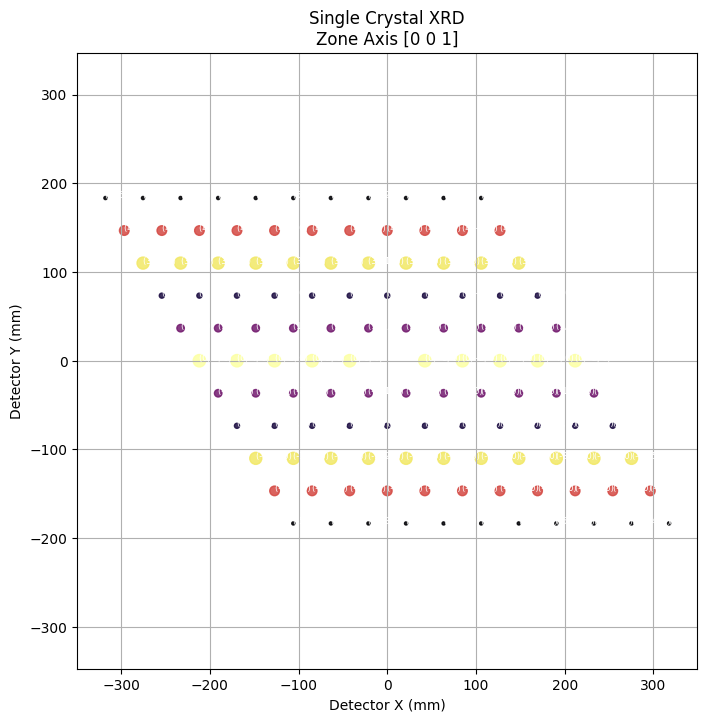

In [ ]:
ZONE_AXIS = np.array([0, 0, 1])
HKL_MAX = 5
RADIUS_CUTOFF_MM = 300
RADIUS_BIN_MM = 0.05

predicted_spots, predicted_shells = predict_zone_axis_spots(
    CIF_FILE,
    zone_axis=ZONE_AXIS,
    wavelength_angstrom=WAVELENGTH_ANGSTROM,
    camera_length_mm=CAMERA_LENGTH_MM,
    hkl_max=HKL_MAX,
    r_bin_mm=RADIUS_BIN_MM,
)

print("Predicted radial shells below the cutoff:\n")
for radius_mm in sorted(predicted_shells):
    if radius_mm < RADIUS_CUTOFF_MM:
        print(f"r ~ {radius_mm:.3f} mm")
        print("  hkl:", sorted(set(predicted_shells[radius_mm])))

spot_x_mm = np.array([spot["x_mm"] for spot in predicted_spots])
spot_y_mm = np.array([spot["y_mm"] for spot in predicted_spots])
spot_intensity = np.array([spot["relative_intensity"] for spot in predicted_spots])
spot_hkl = [spot["hkl"] for spot in predicted_spots]

plt.figure(figsize=(8, 8))
plt.scatter(spot_x_mm, spot_y_mm, s=80 * spot_intensity, c=spot_intensity, cmap="inferno", alpha=0.85)
for index, reflection in enumerate(spot_hkl):
    plt.text(spot_x_mm[index], spot_y_mm[index], f"{reflection}", fontsize=6, color="white")
plt.xlabel("Detector X (mm)")
plt.ylabel("Detector Y (mm)")
plt.title(f"Single Crystal XRD\nZone Axis {ZONE_AXIS}")
plt.axis("equal")
plt.grid(True)
plt.show()

## 6. Overlay predicted or curated rings on the selected wafer image

The original notebook used a manually curated sapphire ring list. Leave `USE_CURATED_RING_LIST = True` for that behavior, or set it to `False` to overlay every predicted shell below the radius cutoff.

Overlay radii in mm    : [73.35, 127.05, 146.7, 152.7, 184.6]
Overlay radii in pixel : [426.45, 738.66, 852.91, 887.79, 1073.26]


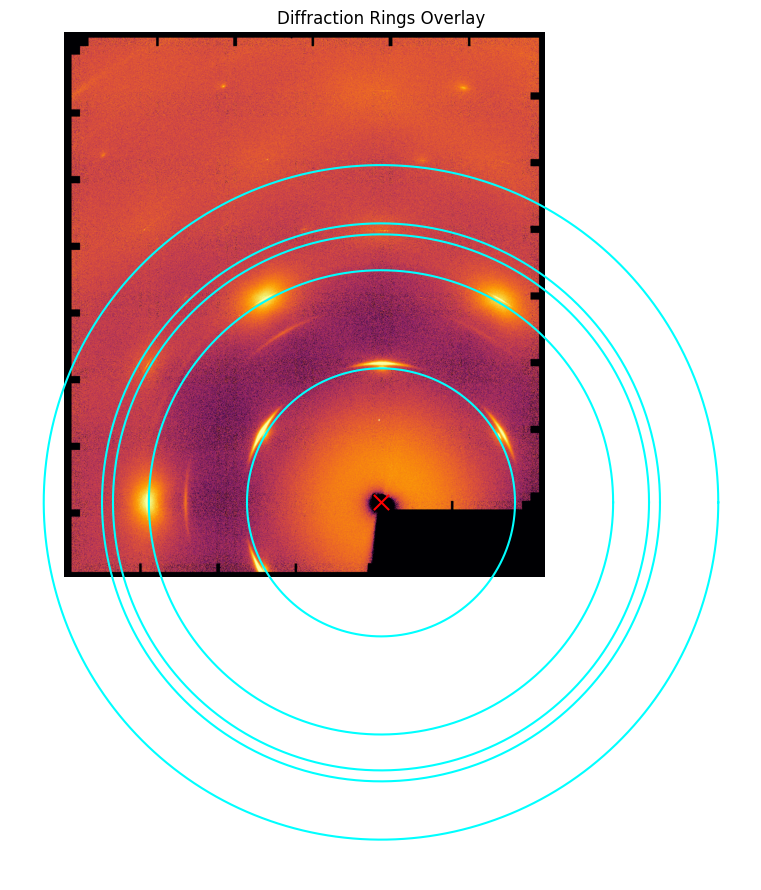

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Diffraction Rings Overlay'}>)

In [ ]:
CURATED_RING_RADII_MM = [73.350, 127.050, 146.700, 152.700, 184.600]
USE_CURATED_RING_LIST = True

if USE_CURATED_RING_LIST:
    overlay_radii_mm = CURATED_RING_RADII_MM
else:
    overlay_radii_mm = [
        radius_mm for radius_mm in sorted(predicted_shells) if radius_mm < RADIUS_CUTOFF_MM
    ]

overlay_radii_pixels = [radius_mm / PIXEL_SIZE_MM for radius_mm in overlay_radii_mm]
print("Overlay radii in mm    :", overlay_radii_mm)
print("Overlay radii in pixel :", [round(radius, 2) for radius in overlay_radii_pixels])

overlay_diffraction_rings(
    wafer_display_image,
    center=beam_center,
    radii_pixels=overlay_radii_pixels,
)

## 7. Optional known-ring radius helper

In [ ]:
def ring_distance_known(lattice_parameter, wavelength, pixel_size, detector_distance, hkl):
    """Estimate ring radius in meters and pixels from simple Bragg geometry."""
    sum_hkl = sum(index ** 2 for index in hkl)
    d_hkl = math.sqrt(sum_hkl)
    radius_m = detector_distance * math.tan(
        2 * math.asin(wavelength * d_hkl / 2 / lattice_parameter)
    )
    radius_pixel = radius_m / pixel_size
    return radius_m, radius_pixel

In [ ]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter, maximum_filter, uniform_filter

# ── Aliases to match the variable names specified ─────────────────────────────
display_image = wafer_display_image      # 2-D float64, [0, 1]
radii         = overlay_radii_pixels     # ring radii in pixels (from Section 6)

# ── Tunable parameters ────────────────────────────────────────────────────────
RING_HALF_WIDTH_PX = 28     # annular band half-width around each ring (px)
GAUSS_SIGMA        = 2.0    # pre-smoothing sigma
BG_FILTER_SIZE     = 61     # uniform-filter footprint for local background
THRESHOLD_SIGMA    = 3.5    # sigma above local band mean → candidate spot
LOCAL_MAX_FOOT     = 15     # NMS footprint (px); sets minimum spot separation
MIN_SPOT_SEP_PX    = 18     # greedy distance filter after NMS
EDGE_MARGIN_PX     = 35     # ignore detections this close to image border
BLACK_CUTOFF       = 0.02   # display_image value below which pixel is dead/masked
MIN_RAW_INTENSITY  = 0.05   # minimum display_image value to accept a spot

# ── 1. Pre-process ────────────────────────────────────────────────────────────
h, w = display_image.shape
smoothed = gaussian_filter(display_image, sigma=GAUSS_SIGMA)

# Radial distance map from beam centre
yy, xx   = np.indices((h, w))
r_map    = np.sqrt((xx - center_x) ** 2 + (yy - center_y) ** 2)

# Dead / masked pixel exclusion (beam stop, detector gaps, black corners)
dead_mask = display_image < BLACK_CUTOFF

# Edge exclusion
edge_mask = np.zeros((h, w), dtype=bool)
edge_mask[:EDGE_MARGIN_PX, :]  = True
edge_mask[-EDGE_MARGIN_PX:, :] = True
edge_mask[:, :EDGE_MARGIN_PX]  = True
edge_mask[:, -EDGE_MARGIN_PX:] = True

bad_mask = dead_mask | edge_mask

# ── 2. Background subtraction (large uniform filter → local baseline) ─────────
local_bg = uniform_filter(smoothed, size=BG_FILTER_SIZE)
bg_sub   = np.clip(smoothed - local_bg, 0, None)   # residual after background

# ── 3. Per-ring spot detection ────────────────────────────────────────────────
records        = []
spot_id_global = 0

for ring_id, ring_r_px in enumerate(radii):
    ring_r_mm = overlay_radii_mm[ring_id]

    # Narrow annular mask for this ring
    in_band = (
        (r_map >= ring_r_px - RING_HALF_WIDTH_PX) &
        (r_map <= ring_r_px + RING_HALF_WIDTH_PX) &
        ~bad_mask
    )
    if not np.any(in_band):
        continue

    # Adaptive threshold: mean + k·sigma of bg-subtracted residual inside band
    band_vals = bg_sub[in_band]
    thresh    = band_vals.mean() + THRESHOLD_SIGMA * band_vals.std()

    # Non-maximum suppression via maximum_filter
    lm_image    = maximum_filter(bg_sub, size=LOCAL_MAX_FOOT)
    is_local_max = (bg_sub == lm_image) & (bg_sub > thresh)

    # Restrict to ring band + minimum raw brightness guard
    candidate_mask = is_local_max & in_band & (display_image >= MIN_RAW_INTENSITY)
    if not np.any(candidate_mask):
        continue

    cand_ys, cand_xs = np.where(candidate_mask)
    cand_vals        = bg_sub[cand_ys, cand_xs]

    # Sort strongest-first so greedy distance filter keeps the best peaks
    order     = np.argsort(-cand_vals)
    cand_xs   = cand_xs[order]
    cand_ys   = cand_ys[order]
    cand_vals = cand_vals[order]

    # Greedy minimum-distance non-max suppression
    kept_x, kept_y = [], []
    for cx, cy in zip(cand_xs, cand_ys):
        too_close = any(
            np.sqrt((cx - ax) ** 2 + (cy - ay) ** 2) < MIN_SPOT_SEP_PX
            for ax, ay in zip(kept_x, kept_y)
        )
        if not too_close:
            kept_x.append(cx)
            kept_y.append(cy)

    # Record accepted spots
    for cx, cy in zip(kept_x, kept_y):
        actual_r_px = np.sqrt((cx - center_x) ** 2 + (cy - center_y) ** 2)
        records.append({
            "spot_id"   : spot_id_global,
            "ring_id"   : ring_id,
            "x"         : int(cx),
            "y"         : int(cy),
            "radius_px" : round(actual_r_px, 2),
            "radius_mm" : round(actual_r_px * PIXEL_SIZE_MM, 3),
            "angle_deg" : round(np.degrees(np.arctan2(cy - center_y, cx - center_x)), 2),
            "intensity" : round(float(display_image[cy, cx]), 5),
        })
        spot_id_global += 1

spots_df = pd.DataFrame(records)

print(f"Total spots detected: {len(spots_df)}")
if not spots_df.empty:
    summary = (
        spots_df.groupby("ring_id")
        .agg(n_spots=("spot_id", "count"),
             mean_intensity=("intensity", "mean"))
        .join(pd.Series(overlay_radii_mm, name="ring_r_mm"))
    )
    print(summary.to_string())
    display(spots_df)


Total spots detected: 17
         n_spots  mean_intensity  ring_r_mm
ring_id                                    
0              5        1.000000      73.35
1              4        1.000000     127.05
2              2        0.991245     146.70
3              5        0.785398     152.70
4              1        0.743520     184.60


,spot_id,ring_id,x,y,radius_px,radius_mm,angle_deg,intensity
0,0,0,608,421,441.47,75.933,155.34,1.00000
1,1,0,650,494,441.80,75.990,144.39,1.00000
2,2,0,979,678,442.26,76.069,93.91,1.00000
3,3,0,1039,678,442.23,76.064,86.14,1.00000
4,4,0,1394,456,442.87,76.174,29.67,1.00000
5,5,1,1389,880,746.99,128.482,59.44,1.00000
6,6,1,639,885,746.49,128.396,119.73,1.00000
7,7,1,264,257,745.47,128.221,178.45,1.00000
8,8,1,264,227,745.26,128.184,-179.25,1.00000
9,9,2,263,670,862.84,148.408,149.86,0.98249


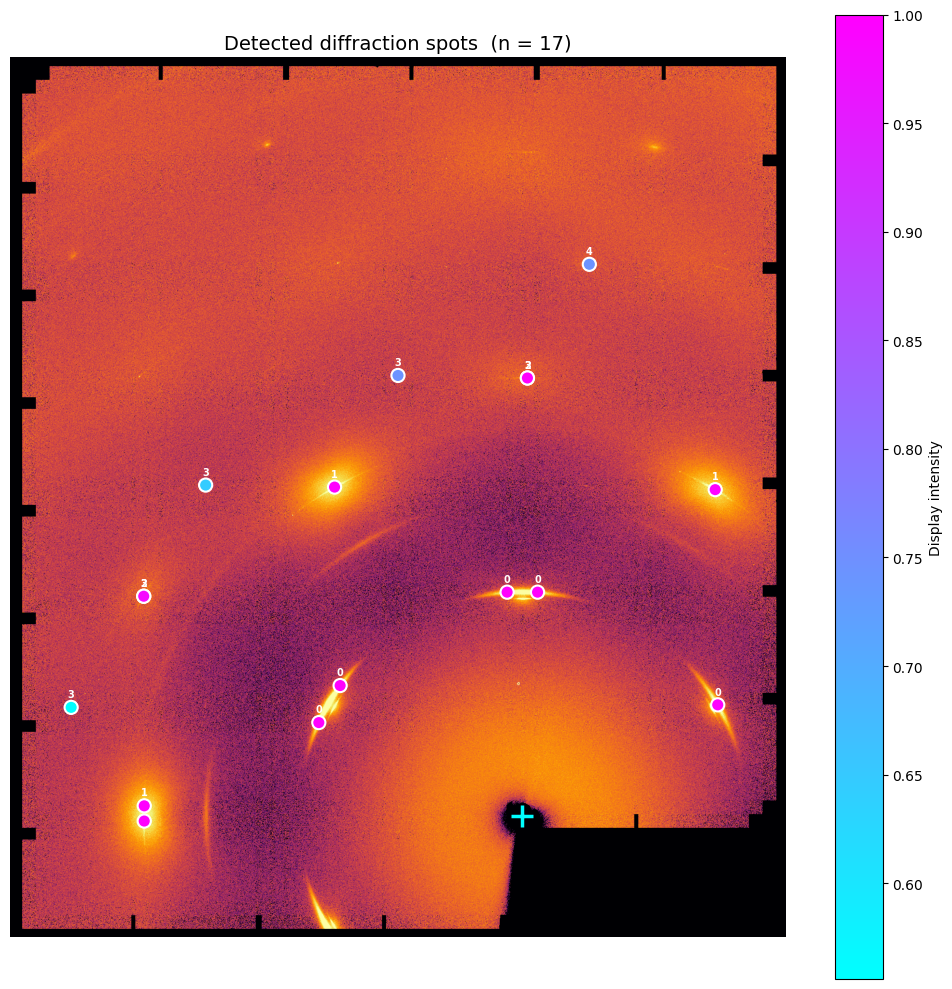

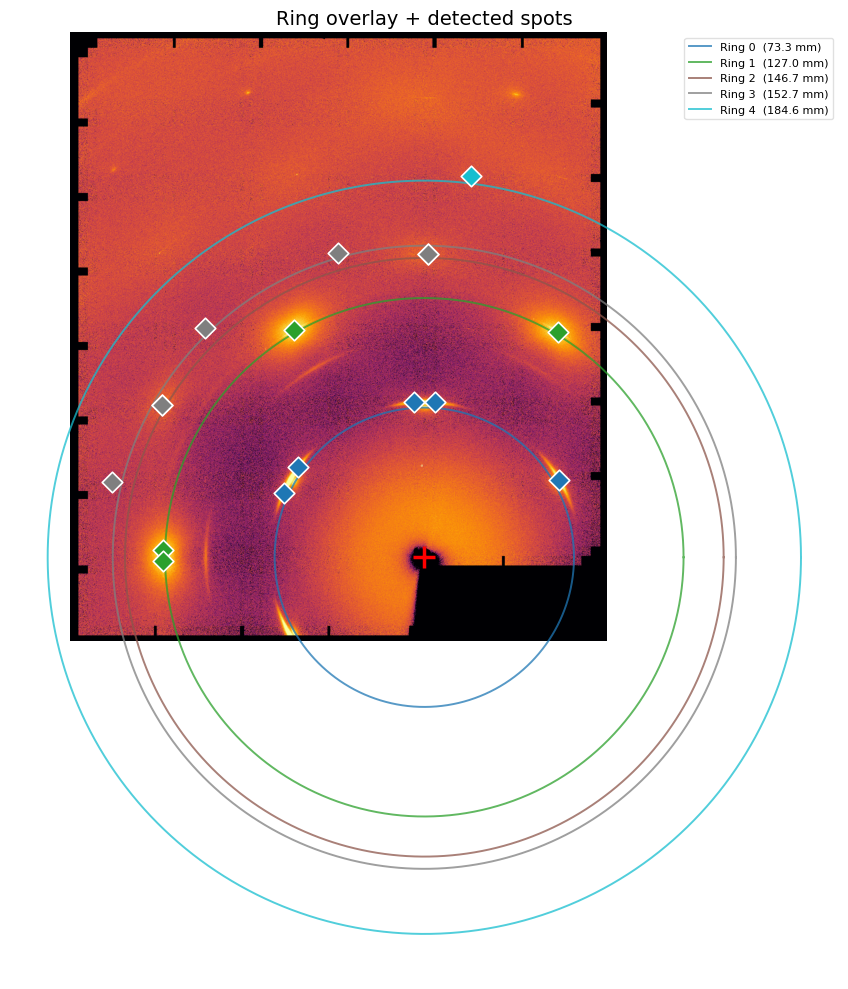


Spot table saved  →  /Users/nannorymunireach/Library/CloudStorage/GoogleDrive-nmunirea@vols.utk.edu/My Drive/Hackathon IRG2/Day 14/detected_spots.csv
Figures saved     →  spots_raw.png  |  spots_rings.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

theta = np.linspace(0, 2 * np.pi, 1000)
ring_colors = plt.cm.tab10(np.linspace(0, 1, len(radii)))

# ── Figure 1: raw image + spots ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(display_image, cmap="inferno", origin="lower")
ax.scatter(center_x, center_y, c="cyan", s=250, marker="+",
           linewidths=2.5, zorder=7, label="Beam centre")

if not spots_df.empty:
    sc = ax.scatter(
        spots_df["x"], spots_df["y"],
        c=spots_df["intensity"], cmap="cool",
        s=90, marker="o", linewidths=1.5,
        edgecolors="white", zorder=6,
    )
    plt.colorbar(sc, ax=ax, label="Display intensity")
    # Label each spot with its ring_id
    for _, row in spots_df.iterrows():
        ax.annotate(
            str(int(row["ring_id"])),
            (row["x"], row["y"]),
            color="white", fontsize=7, fontweight="bold",
            ha="center", va="bottom",
            xytext=(0, 6), textcoords="offset points",
        )

ax.set_title(f"Detected diffraction spots  (n = {len(spots_df)})", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("spots_raw.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: ring overlay + spots ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(display_image, cmap="inferno", origin="lower")

for ring_id, ring_r_px in enumerate(radii):
    color = ring_colors[ring_id % len(ring_colors)]
    ax.plot(
        center_x + ring_r_px * np.cos(theta),
        center_y + ring_r_px * np.sin(theta),
        color=color, linewidth=1.4, alpha=0.75,
        label=f"Ring {ring_id}  ({overlay_radii_mm[ring_id]:.1f} mm)",
    )
    if not spots_df.empty:
        ring_spots = spots_df[spots_df["ring_id"] == ring_id]
        ax.scatter(
            ring_spots["x"], ring_spots["y"],
            color=color, s=110, marker="D",
            edgecolors="white", linewidths=1.2, zorder=6,
        )

ax.scatter(center_x, center_y, c="red", s=250, marker="+",
           linewidths=2.5, zorder=7)
ax.legend(loc="upper right", fontsize=8, framealpha=0.6)
ax.set_title("Ring overlay + detected spots", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("spots_rings.png", dpi=150, bbox_inches="tight")
plt.show()

# ── CSV export ────────────────────────────────────────────────────────────────
csv_path = WORKSPACE_ROOT / "detected_spots.csv"
spots_df.to_csv(csv_path, index=False)
print(f"\nSpot table saved  →  {csv_path}")
print(f"Figures saved     →  spots_raw.png  |  spots_rings.png")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import (
    gaussian_filter, maximum_filter, uniform_filter,
    label as ndi_label, binary_dilation
)

# ── Parameters ────────────────────────────────────────────────────────────────
RING_HALF_WIDTH_PX  = 28
GAUSS_SIGMA         = 2.0
BG_FILTER_SIZE      = 61
THRESHOLD_SIGMA     = 3.5
LOCAL_MAX_FOOT      = 15
MIN_SPOT_SEP_PX     = 18
EDGE_MARGIN_PX      = 35
BLACK_CUTOFF        = 0.02    # pixels below this are dead / masked
MIN_RAW_INTENSITY   = 0.05
SHADOW_MIN_AREA_PX  = 800     # connected dark blobs larger than this = shadow arm
SHADOW_DILATION_PX  = 8       # grow each shadow by this many pixels
CROP_HALF_PX        = 40      # half-side of the crop box around each spot


def build_bad_mask(display_img, edge_margin=EDGE_MARGIN_PX,
                   black_cutoff=BLACK_CUTOFF,
                   shadow_min_area=SHADOW_MIN_AREA_PX,
                   shadow_dilation=SHADOW_DILATION_PX):
    """Return a boolean mask of pixels to ignore:
    dead pixels, image edges, beam-stop body, and shadow arms."""
    h, w = display_img.shape

    # 1. Raw dark-pixel mask
    dark = display_img < black_cutoff

    # 2. Split into isolated bad pixels vs. large connected shadows
    labeled, n = ndi_label(dark)
    sizes      = np.bincount(labeled.ravel())   # size of each component
    shadow_mask = np.zeros((h, w), dtype=bool)
    for comp_id in range(1, n + 1):
        if sizes[comp_id] >= shadow_min_area:
            shadow_mask |= (labeled == comp_id)

    # 3. Dilate shadows to swallow their bright fringes / penumbra
    if shadow_dilation > 0:
        shadow_mask = binary_dilation(shadow_mask, iterations=shadow_dilation)

    # 4. Edge exclusion
    edge_mask = np.zeros((h, w), dtype=bool)
    edge_mask[:edge_margin, :]  = True
    edge_mask[-edge_margin:, :] = True
    edge_mask[:, :edge_margin]  = True
    edge_mask[:, -edge_margin:] = True

    # Combine: individual dead pixels (small dark blobs) + shadows + edges
    isolated_dead = dark & ~shadow_mask   # small dead-pixel clusters
    return isolated_dead | shadow_mask | edge_mask


def detect_spots(display_img, cx, cy, ring_radii_px, ring_radii_mm,
                 ring_half_width=RING_HALF_WIDTH_PX,
                 gauss_sigma=GAUSS_SIGMA,
                 bg_size=BG_FILTER_SIZE,
                 thresh_sigma=THRESHOLD_SIGMA,
                 lm_foot=LOCAL_MAX_FOOT,
                 min_sep=MIN_SPOT_SEP_PX,
                 min_raw=MIN_RAW_INTENSITY):
    """Full detection pipeline. Returns a DataFrame of spots."""
    h, w   = display_img.shape
    bad    = build_bad_mask(display_img)
    smooth = gaussian_filter(display_img, sigma=gauss_sigma)
    yy, xx = np.indices((h, w))
    r_map  = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)

    local_bg = uniform_filter(smooth, size=bg_size)
    bg_sub   = np.clip(smooth - local_bg, 0, None)

    records, spot_id = [], 0
    for ring_id, (r_px, r_mm) in enumerate(zip(ring_radii_px, ring_radii_mm)):
        in_band = (
            (r_map >= r_px - ring_half_width) &
            (r_map <= r_px + ring_half_width) &
            ~bad
        )
        if not np.any(in_band):
            continue

        band_vals = bg_sub[in_band]
        thresh    = band_vals.mean() + thresh_sigma * band_vals.std()

        lm        = maximum_filter(bg_sub, size=lm_foot)
        cand_mask = (bg_sub == lm) & (bg_sub > thresh) & in_band & (display_img >= min_raw)
        if not np.any(cand_mask):
            continue

        cys, cxs = np.where(cand_mask)
        vals     = bg_sub[cys, cxs]
        order    = np.argsort(-vals)
        cxs, cys = cxs[order], cys[order]

        kept_x, kept_y = [], []
        for px, py in zip(cxs, cys):
            if not any(np.sqrt((px-ax)**2 + (py-ay)**2) < min_sep
                       for ax, ay in zip(kept_x, kept_y)):
                kept_x.append(px)
                kept_y.append(py)

        for px, py in zip(kept_x, kept_y):
            actual_r = np.sqrt((px - cx)**2 + (py - cy)**2)
            records.append({
                "spot_id"   : spot_id,
                "ring_id"   : ring_id,
                "x"         : int(px),
                "y"         : int(py),
                "radius_px" : round(actual_r, 2),
                "radius_mm" : round(actual_r * PIXEL_SIZE_MM, 3),
                "angle_deg" : round(np.degrees(np.arctan2(py - cy, px - cx)), 2),
                "intensity" : round(float(display_img[py, px]), 5),
            })
            spot_id += 1

    return pd.DataFrame(records)


print("Helper functions loaded: build_bad_mask(), detect_spots()")


Helper functions loaded: build_bad_mask(), detect_spots()


In [ ]:
import tifffile
from pathlib import Path
from math import ceil

ADDITIONAL_DIR = TEST_TIFFS / "Addtinal Test"
tiff_paths     = sorted(ADDITIONAL_DIR.glob("*.tiff"))
print(f"Found {len(tiff_paths)} files in Additional Test:")
for p in tiff_paths:
    print(" ", p.name)

# ── Shared geometry from the main notebook ────────────────────────────────────
# center_x, center_y, overlay_radii_pixels, overlay_radii_mm already in scope

all_spot_tables = {}   # {filename: DataFrame}
all_display_imgs = {}

for tiff_path in tiff_paths:
    sample_name = tiff_path.stem

    # ── 1. Load ───────────────────────────────────────────────────────────────
    raw_arr, _, _, disp_img = load_and_view_tiff(
        tiff_path,
        percentile_low=1, percentile_high=99.9,
        show_plot=False,          # we will plot manually below
    )
    all_display_imgs[sample_name] = disp_img

    # ── 2. Build shadow mask (for the diagnostic overlay) ─────────────────────
    bad = build_bad_mask(disp_img)

    # ── 3. Detect spots ───────────────────────────────────────────────────────
    spots = detect_spots(
        disp_img,
        cx=center_x, cy=center_y,
        ring_radii_px=overlay_radii_pixels,
        ring_radii_mm=overlay_radii_mm,
    )
    all_spot_tables[sample_name] = spots
    print(f"\n{sample_name}: {len(spots)} spots detected")
    if not spots.empty:
        print(spots.groupby("ring_id")[["spot_id"]].count()
              .rename(columns={"spot_id":"n_spots"}).T.to_string())

    # ── 4. Three-panel figure: original | shadow mask | spots + rings ─────────
    theta = np.linspace(0, 2 * np.pi, 1000)
    ring_colors = plt.cm.tab10(np.linspace(0, 1, len(overlay_radii_pixels)))

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.suptitle(sample_name, fontsize=13, fontweight="bold")

    # Panel 1 — original
    ax = axes[0]
    ax.imshow(disp_img, cmap="inferno", origin="lower")
    ax.scatter(center_x, center_y, c="cyan", s=200, marker="+", linewidths=2.5, zorder=5)
    ax.set_title("1. Original image")
    ax.set_axis_off()

    # Panel 2 — shadow / bad-pixel mask overlay
    ax = axes[1]
    ax.imshow(disp_img, cmap="inferno", origin="lower")
    ax.imshow(bad, cmap="cool", alpha=0.45, origin="lower")
    ax.scatter(center_x, center_y, c="cyan", s=200, marker="+", linewidths=2.5, zorder=5)
    ax.set_title("2. Shadow + dead-pixel mask (blue = excluded)")
    ax.set_axis_off()

    # Panel 3 — rings + detected spots
    ax = axes[2]
    ax.imshow(disp_img, cmap="inferno", origin="lower")
    for ring_id, r_px in enumerate(overlay_radii_pixels):
        color = ring_colors[ring_id % len(ring_colors)]
        ax.plot(center_x + r_px * np.cos(theta),
                center_y + r_px * np.sin(theta),
                color=color, linewidth=1.2, alpha=0.7,
                label=f"Ring {ring_id} ({overlay_radii_mm[ring_id]:.1f} mm)")
        if not spots.empty:
            rs = spots[spots["ring_id"] == ring_id]
            ax.scatter(rs["x"], rs["y"],
                       color=color, s=100, marker="D",
                       edgecolors="white", linewidths=1.2, zorder=6)
    ax.scatter(center_x, center_y, c="red", s=200, marker="+", linewidths=2.5, zorder=7)
    ax.legend(loc="upper right", fontsize=7, framealpha=0.55)
    ax.set_title(f"3. Detected spots  (n={len(spots)})")
    ax.set_axis_off()

    plt.tight_layout()
    out_fig = WORKSPACE_ROOT / f"spots_{sample_name}.png"
    plt.savefig(out_fig, dpi=150, bbox_inches="tight")
    plt.show()

    # ── 5. Spot crops grid ────────────────────────────────────────────────────
    if spots.empty:
        print(f"  No spots to crop for {sample_name}")
        continue

    h_img, w_img = disp_img.shape
    half = CROP_HALF_PX
    n_spots = len(spots)
    n_cols  = min(8, n_spots)
    n_rows  = ceil(n_spots / n_cols)

    fig_c, axes_c = plt.subplots(
        n_rows, n_cols,
        figsize=(2.2 * n_cols, 2.2 * n_rows),
        squeeze=False,
    )
    fig_c.suptitle(f"{sample_name} — spot crops  ({n_spots} spots)", fontsize=11)

    for idx, (_, row) in enumerate(spots.iterrows()):
        px, py = int(row["x"]), int(row["y"])
        y0, y1 = max(0, py - half), min(h_img, py + half)
        x0, x1 = max(0, px - half), min(w_img, px + half)
        crop    = disp_img[y0:y1, x0:x1]

        r, c = divmod(idx, n_cols)
        axc  = axes_c[r][c]
        axc.imshow(crop, cmap="inferno", origin="lower")
        # Mark centre of spot relative to crop
        axc.scatter(px - x0, py - y0, c="cyan", s=60, marker="+",
                    linewidths=1.5, zorder=5)
        axc.set_title(
            f"S{int(row['spot_id'])}  R{int(row['ring_id'])}\n"
            f"{row['radius_mm']:.1f} mm  {row['angle_deg']:.0f}°",
            fontsize=6,
        )
        axc.set_axis_off()

    # Hide any unused subplots
    for idx in range(n_spots, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes_c[r][c].set_visible(False)

    plt.tight_layout()
    out_crops = WORKSPACE_ROOT / f"crops_{sample_name}.png"
    plt.savefig(out_crops, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Crops figure saved → {out_crops.name}")

# ── 6. Combined CSV for all samples ──────────────────────────────────────────
if all_spot_tables:
    combined = pd.concat(
        [df.assign(sample=name) for name, df in all_spot_tables.items()],
        ignore_index=True,
    )
    csv_path = WORKSPACE_ROOT / "detected_spots_additional.csv"
    combined.to_csv(csv_path, index=False)
    print(f"\nCombined spot table ({len(combined)} rows) saved → {csv_path.name}")
    display(combined)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

# ── Polar crop parameters ─────────────────────────────────────────────────────
RADIAL_HALF_WIDTH_PX  = 20    # ± px around the ring radius
ANGULAR_HALF_WIDTH_DEG = 5.0  # ± degrees around the spot angle


def build_polar_sector_mask(h, w, cx, cy, r_spot, theta_spot,
                            radial_half=RADIAL_HALF_WIDTH_PX,
                            angular_half=ANGULAR_HALF_WIDTH_DEG):
    """
    Boolean mask: True where
        |radius_map  - r_spot    | <= radial_half
        |angle_map   - theta_spot| <= angular_half   (handles wrap-around)
    """
    yy, xx    = np.indices((h, w))
    r_map     = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    theta_map = np.degrees(np.arctan2(yy - cy, xx - cx))  # [-180, 180]

    radial_ok = np.abs(r_map - r_spot) <= radial_half

    # Wrap-safe angular difference  →  result always in [0, 180]
    ang_diff = np.abs(((theta_map - theta_spot + 180.0) % 360.0) - 180.0)
    angular_ok = ang_diff <= angular_half

    return radial_ok & angular_ok


def tight_bbox(mask):
    """Return (y0, y1, x0, x1) of the tightest bounding box around True pixels."""
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any():
        return None
    y0, y1 = np.where(rows)[0][[0, -1]]
    x0, x1 = np.where(cols)[0][[0, -1]]
    return y0, y1 + 1, x0, x1 + 1


def plot_polar_crops(sample_name, display_img, spots_df,
                     cx, cy,
                     radial_half=RADIAL_HALF_WIDTH_PX,
                     angular_half=ANGULAR_HALF_WIDTH_DEG,
                     save_dir=None):
    """
    For every detected spot:
      • build the polar-sector mask
      • black-out everything outside the sector
      • show the tight bounding-box crop of that arc segment
    Also shows one full-image diagnostic (all sector masks overlaid).
    """
    if spots_df.empty:
        print(f"  {sample_name}: no spots to crop.")
        return

    h, w = display_img.shape
    n_spots = len(spots_df)

    # ── Panel 0: full image with all sector masks overlaid in colour ──────────
    sector_overlay = np.zeros((h, w), dtype=float)
    for _, row in spots_df.iterrows():
        mask = build_polar_sector_mask(h, w, cx, cy,
                                       row["radius_px"], row["angle_deg"],
                                       radial_half, angular_half)
        sector_overlay[mask] = row["ring_id"] + 1   # non-zero per ring

    fig0, ax0 = plt.subplots(figsize=(9, 9))
    ax0.imshow(display_img,    cmap="inferno", origin="lower", alpha=0.85)
    ax0.imshow(sector_overlay, cmap="tab10",   origin="lower",
               alpha=0.45, vmin=0, vmax=len(np.unique(sector_overlay)))
    ax0.scatter(cx, cy, c="cyan", s=220, marker="+", linewidths=2.5, zorder=6)
    ax0.set_title(f"{sample_name}\nAll polar-sector masks  "
                  f"(±{radial_half} px  ±{angular_half}°)", fontsize=11)
    ax0.set_axis_off()
    plt.tight_layout()
    if save_dir:
        fig0.savefig(Path(save_dir) / f"polar_masks_{sample_name}.png",
                     dpi=150, bbox_inches="tight")
    plt.show()

    # ── Per-spot arc crops ────────────────────────────────────────────────────
    n_cols = min(6, n_spots)
    n_rows = ceil(n_spots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.0 * n_cols, 2.8 * n_rows),
                             squeeze=False)
    fig.suptitle(f"{sample_name} — polar-sector crops  "
                 f"(±{radial_half} px  ±{angular_half}°)", fontsize=11)

    for idx, (_, row) in enumerate(spots_df.iterrows()):
        r_px, theta = row["radius_px"], row["angle_deg"]

        # Build the arc mask and apply it
        mask = build_polar_sector_mask(h, w, cx, cy, r_px, theta,
                                       radial_half, angular_half)
        arc_img = display_img * mask           # outside sector → 0

        # Tight bounding box around the arc
        bb = tight_bbox(mask)
        if bb is None:
            continue
        y0, y1, x0, x1 = bb
        crop      = arc_img[y0:y1, x0:x1]
        mask_crop = mask[y0:y1, x0:x1]

        # Show with NaN outside the mask for a clean background
        crop_display = crop.astype(float)
        crop_display[~mask_crop] = np.nan

        r, c  = divmod(idx, n_cols)
        axc   = axes[r][c]
        axc.imshow(crop_display, cmap="inferno", origin="lower",
                   vmin=0, vmax=1)

        # Mark the spot centre relative to the crop
        spot_col = int(row["x"]) - x0
        spot_row = int(row["y"]) - y0
        axc.scatter(spot_col, spot_row, c="cyan", s=60, marker="+",
                    linewidths=1.8, zorder=5)

        axc.set_title(
            f"S{int(row['spot_id'])}  R{int(row['ring_id'])}\n"
            f"r={row['radius_mm']:.1f} mm  θ={theta:.1f}°",
            fontsize=7,
        )
        axc.set_axis_off()

    for idx in range(n_spots, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r][c].set_visible(False)

    plt.tight_layout()
    if save_dir:
        fig.savefig(Path(save_dir) / f"polar_crops_{sample_name}.png",
                    dpi=150, bbox_inches="tight")
    plt.show()

print("Polar-sector crop functions loaded.")


Polar-sector crop functions loaded.


In [ ]:
# ── Re-run for the wafer images already in scope ──────────────────────────────
# If you already have all_spot_tables / all_display_imgs from Cell B, run this:

for sample_name, spots in all_spot_tables.items():
    disp_img = all_display_imgs[sample_name]
    print(f"\n── {sample_name}  ({len(spots)} spots) ──")
    plot_polar_crops(
        sample_name   = sample_name,
        display_img   = disp_img,
        spots_df      = spots,
        cx            = center_x,
        cy            = center_y,
        radial_half   = RADIAL_HALF_WIDTH_PX,
        angular_half  = ANGULAR_HALF_WIDTH_DEG,
        save_dir      = WORKSPACE_ROOT,
    )


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, uniform_filter, uniform_filter1d
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
#  SUPPRESSION PARAMETERS  — adjust these
# ══════════════════════════════════════════════════════════════════════════════
SUP_RADIAL_HALF_PX   = 30     # ± px around the ring radius (annular band width)
SUP_ANGULAR_HALF_DEG = 6.0    # ± degrees around the spot centre (wedge width)
SUP_REDUCTION        = 1.0    # 0 = no change | 1.0 = full replace with background
SUP_FEATHER_SIGMA    = 6.0    # Gaussian blur of the mask edges (smooth blend)
SUP_RADIAL_BINS      = 1200   # number of radial bins for azimuthal background
SUP_PROFILE_SMOOTH   = 15     # 1-D smoothing window on the radial profile (bins)
# ══════════════════════════════════════════════════════════════════════════════


# ── 1. Ring-following azimuthal background ────────────────────────────────────
def azimuthal_background(display_img, cx, cy,
                          n_bins=SUP_RADIAL_BINS,
                          smooth_win=SUP_PROFILE_SMOOTH):
    """
    Compute the azimuthal MEDIAN at each radius and map it back to 2-D.
    Median is robust to bright spots so they don't inflate the background.
    """
    h, w   = display_img.shape
    yy, xx = np.indices((h, w))
    r_map  = np.sqrt((xx - cx)**2 + (yy - cy)**2)

    r_flat  = r_map.ravel()
    v_flat  = display_img.ravel()
    r_max   = r_flat.max()

    bins     = np.linspace(0, r_max + 1, n_bins + 1)
    bin_idx  = np.clip(np.digitize(r_flat, bins) - 1, 0, n_bins - 1)

    radial_median = np.zeros(n_bins)
    for i in range(n_bins):
        sel = v_flat[bin_idx == i]
        if sel.size > 0:
            radial_median[i] = np.median(sel)

    # Fill any empty bins by linear interpolation
    valid = radial_median > 0
    if valid.any():
        x_all   = np.arange(n_bins)
        radial_median = np.interp(x_all, x_all[valid], radial_median[valid])

    # Smooth the 1-D profile
    radial_median = uniform_filter1d(radial_median, size=smooth_win)

    # Map each pixel to its radial bin's median value
    bin_map_2d = np.clip(np.digitize(r_map, bins) - 1, 0, n_bins - 1)
    background = radial_median[bin_map_2d]
    return background.astype(np.float64)


# ── 2. Polar-sector suppression mask ─────────────────────────────────────────
def build_polar_suppression_mask(h, w, cx, cy, spots_df,
                                  radial_half=SUP_RADIAL_HALF_PX,
                                  angular_half=SUP_ANGULAR_HALF_DEG,
                                  feather_sigma=SUP_FEATHER_SIGMA):
    """
    One arc-shaped sector per spot, merged and Gaussian-feathered.
    Returns hard (binary) and soft (float [0,1]) masks.
    """
    yy, xx    = np.indices((h, w))
    r_map     = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    theta_map = np.degrees(np.arctan2(yy - cy, xx - cx))

    hard = np.zeros((h, w), dtype=np.float32)

    for _, row in spots_df.iterrows():
        r_spot     = row["radius_px"]
        theta_spot = row["angle_deg"]

        radial_ok  = np.abs(r_map - r_spot) <= radial_half
        ang_diff   = np.abs(((theta_map - theta_spot + 180.0) % 360.0) - 180.0)
        angular_ok = ang_diff <= angular_half
        hard[radial_ok & angular_ok] = 1.0

    # Feather: blur then re-normalise to [0, 1]
    soft = gaussian_filter(hard, sigma=feather_sigma)
    if soft.max() > 0:
        soft = soft / soft.max()
    return hard, soft


# ── 3. Suppress + reconstruct ─────────────────────────────────────────────────
def suppress_spots_azimuthal(display_img, cx, cy, spots_df,
                              reduction    = SUP_REDUCTION,
                              radial_half  = SUP_RADIAL_HALF_PX,
                              angular_half = SUP_ANGULAR_HALF_DEG,
                              feather_sigma= SUP_FEATHER_SIGMA):
    """
    Replace spot pixels with the ring-following azimuthal median background.
    corrected = original*(1 - weight)  +  background*weight
    where  weight = soft_mask * reduction_factor
    """
    h, w = display_img.shape

    print("  Computing azimuthal background …", end="", flush=True)
    background = azimuthal_background(display_img, cx, cy)
    print(" done")

    hard, soft = build_polar_suppression_mask(h, w, cx, cy, spots_df,
                                               radial_half, angular_half,
                                               feather_sigma)

    weight    = soft * reduction
    corrected = display_img * (1.0 - weight) + background * weight

    # Keep SAME dynamic range as original — no renormalisation
    corrected = np.clip(corrected, 0.0, display_img.max())
    return hard, soft, background, corrected


# ── 4. Five-panel comparison figure ──────────────────────────────────────────
def plot_full_comparison(sample_name, display_img, background,
                          hard_mask, soft_mask, corrected_img,
                          spots_df, cx, cy, save_dir=None):
    vmax = display_img.max()
    fig, axes = plt.subplots(1, 5, figsize=(32, 7))
    fig.suptitle(
        f"{sample_name}\n"
        f"Polar-sector suppression  "
        f"±{SUP_RADIAL_HALF_PX} px  ±{SUP_ANGULAR_HALF_DEG}°  "
        f"reduction={SUP_REDUCTION:.0%}  feather σ={SUP_FEATHER_SIGMA}",
        fontsize=11, fontweight="bold",
    )

    panels = [
        (display_img,  "inferno", "1. Original",                            True),
        (background,   "inferno", "2. Azimuthal background\n(ring-following)", False),
        (hard_mask,    "hot",     "3. Hard polar-sector mask\n(binary)",     True),
        (soft_mask,    "hot",     "4. Soft mask (feathered)",                True),
        (corrected_img,"inferno", "5. Reconstructed\n(spots suppressed)",    False),
    ]

    for ax, (img, cmap, title, show_spots) in zip(axes, panels):
        im = ax.imshow(img, cmap=cmap, origin="lower",
                       vmin=0, vmax=img.max() if img.max() > 0 else 1)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        ax.scatter(cx, cy, c="cyan", s=160, marker="+",
                   linewidths=2.0, zorder=6)
        if show_spots and not spots_df.empty:
            ax.scatter(spots_df["x"], spots_df["y"],
                       c="lime", s=55, marker="o",
                       edgecolors="white", linewidths=0.8, zorder=5, alpha=0.85)
        ax.set_title(title, fontsize=9)
        ax.set_axis_off()

    plt.tight_layout()
    if save_dir:
        out = Path(save_dir) / f"suppression_full_{sample_name}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Saved → {out.name}")
    plt.show()


# ── 5. Clean before / after + difference ─────────────────────────────────────
def plot_before_after_diff(sample_name, display_img, corrected_img,
                            spots_df, cx, cy, save_dir=None):
    diff = display_img - corrected_img   # positive = what was removed

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle(f"{sample_name} — Before / After / Removed",
                 fontsize=13, fontweight="bold")

    configs = [
        (display_img,   "inferno", "BEFORE  (original)",
         True,  "green", f"{len(spots_df)} detected spots"),
        (corrected_img, "inferno", "AFTER  (spots suppressed)",
         False, None,    None),
        (diff,          "hot",     "REMOVED  (before − after)\nbright = more suppression",
         True,  "cyan",  "spot centres"),
    ]

    for ax, (img, cmap, title, show_spots, color, label) in zip(axes, configs):
        vmax_panel = np.percentile(img, 99.5) if img.max() > 0 else 1
        im = ax.imshow(img, cmap=cmap, origin="lower", vmin=0, vmax=vmax_panel)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        ax.scatter(cx, cy, c="cyan", s=200, marker="+",
                   linewidths=2.5, zorder=6)
        if show_spots and not spots_df.empty:
            ax.scatter(spots_df["x"], spots_df["y"],
                       c=color, s=80, marker="o",
                       edgecolors="white", linewidths=1.1, zorder=5,
                       label=label)
            ax.legend(loc="upper right", fontsize=8, framealpha=0.6)
        ax.set_title(title, fontsize=11)
        ax.set_axis_off()

    plt.tight_layout()
    if save_dir:
        out = Path(save_dir) / f"before_after_{sample_name}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Saved → {out.name}")
    plt.show()

    # ── Intensity report ──────────────────────────────────────────────────
    if not spots_df.empty:
        sy = spots_df["y"].astype(int).values
        sx = spots_df["x"].astype(int).values
        orig_mean = display_img[sy, sx].mean()
        corr_mean = corrected_img[sy, sx].mean()
        print(f"  Spot-centre mean intensity: "
              f"before={orig_mean:.4f} → after={corr_mean:.4f}  "
              f"({(orig_mean-corr_mean)/orig_mean*100:.1f}% reduction)")
        print(f"  Whole-image mean:           "
              f"before={display_img.mean():.4f} → after={corrected_img.mean():.4f}")


print("Suppression functions loaded (azimuthal background, polar-sector mask).")


Suppression functions loaded (azimuthal background, polar-sector mask).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, uniform_filter, uniform_filter1d
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
#  SUPPRESSION PARAMETERS  — adjust these
# ══════════════════════════════════════════════════════════════════════════════
SUP_RADIAL_HALF_PX   = 30     # ± px around the ring radius (annular band width)
SUP_ANGULAR_HALF_DEG = 6.0    # ± degrees around the spot centre (wedge width)
SUP_REDUCTION        = 1.0    # 0 = no change | 1.0 = full replace with background
SUP_FEATHER_SIGMA    = 6.0    # Gaussian blur of the mask edges (smooth blend)
SUP_RADIAL_BINS      = 1200   # number of radial bins for azimuthal background
SUP_PROFILE_SMOOTH   = 15     # 1-D smoothing window on the radial profile (bins)
# ══════════════════════════════════════════════════════════════════════════════


# ── 1. Ring-following azimuthal background ────────────────────────────────────
def azimuthal_background(display_img, cx, cy,
                          n_bins=SUP_RADIAL_BINS,
                          smooth_win=SUP_PROFILE_SMOOTH):
    """
    Compute the azimuthal MEDIAN at each radius and map it back to 2-D.
    Median is robust to bright spots so they don't inflate the background.
    """
    h, w   = display_img.shape
    yy, xx = np.indices((h, w))
    r_map  = np.sqrt((xx - cx)**2 + (yy - cy)**2)

    r_flat  = r_map.ravel()
    v_flat  = display_img.ravel()
    r_max   = r_flat.max()

    bins     = np.linspace(0, r_max + 1, n_bins + 1)
    bin_idx  = np.clip(np.digitize(r_flat, bins) - 1, 0, n_bins - 1)

    radial_median = np.zeros(n_bins)
    for i in range(n_bins):
        sel = v_flat[bin_idx == i]
        if sel.size > 0:
            radial_median[i] = np.median(sel)

    # Fill any empty bins by linear interpolation
    valid = radial_median > 0
    if valid.any():
        x_all   = np.arange(n_bins)
        radial_median = np.interp(x_all, x_all[valid], radial_median[valid])

    # Smooth the 1-D profile
    radial_median = uniform_filter1d(radial_median, size=smooth_win)

    # Map each pixel to its radial bin's median value
    bin_map_2d = np.clip(np.digitize(r_map, bins) - 1, 0, n_bins - 1)
    background = radial_median[bin_map_2d]
    return background.astype(np.float64)


# ── 2. Polar-sector suppression mask ─────────────────────────────────────────
def build_polar_suppression_mask(h, w, cx, cy, spots_df,
                                  radial_half=SUP_RADIAL_HALF_PX,
                                  angular_half=SUP_ANGULAR_HALF_DEG,
                                  feather_sigma=SUP_FEATHER_SIGMA):
    """
    One arc-shaped sector per spot, merged and Gaussian-feathered.
    Returns hard (binary) and soft (float [0,1]) masks.
    """
    yy, xx    = np.indices((h, w))
    r_map     = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    theta_map = np.degrees(np.arctan2(yy - cy, xx - cx))

    hard = np.zeros((h, w), dtype=np.float32)

    for _, row in spots_df.iterrows():
        r_spot     = row["radius_px"]
        theta_spot = row["angle_deg"]

        radial_ok  = np.abs(r_map - r_spot) <= radial_half
        ang_diff   = np.abs(((theta_map - theta_spot + 180.0) % 360.0) - 180.0)
        angular_ok = ang_diff <= angular_half
        hard[radial_ok & angular_ok] = 1.0

    # Feather: blur then re-normalise to [0, 1]
    soft = gaussian_filter(hard, sigma=feather_sigma)
    if soft.max() > 0:
        soft = soft / soft.max()
    return hard, soft


# ── 3. Suppress + reconstruct ─────────────────────────────────────────────────
def suppress_spots_azimuthal(display_img, cx, cy, spots_df,
                              reduction    = SUP_REDUCTION,
                              radial_half  = SUP_RADIAL_HALF_PX,
                              angular_half = SUP_ANGULAR_HALF_DEG,
                              feather_sigma= SUP_FEATHER_SIGMA):
    """
    Replace spot pixels with the ring-following azimuthal median background.
    corrected = original*(1 - weight)  +  background*weight
    where  weight = soft_mask * reduction_factor
    """
    h, w = display_img.shape

    print("  Computing azimuthal background …", end="", flush=True)
    background = azimuthal_background(display_img, cx, cy)
    print(" done")

    hard, soft = build_polar_suppression_mask(h, w, cx, cy, spots_df,
                                               radial_half, angular_half,
                                               feather_sigma)

    weight    = soft * reduction
    corrected = display_img * (1.0 - weight) + background * weight

    # Keep SAME dynamic range as original — no renormalisation
    corrected = np.clip(corrected, 0.0, display_img.max())
    return hard, soft, background, corrected


# ── 4. Five-panel comparison figure ──────────────────────────────────────────
def plot_full_comparison(sample_name, display_img, background,
                          hard_mask, soft_mask, corrected_img,
                          spots_df, cx, cy, save_dir=None):
    vmax = display_img.max()
    fig, axes = plt.subplots(1, 5, figsize=(32, 7))
    fig.suptitle(
        f"{sample_name}\n"
        f"Polar-sector suppression  "
        f"±{SUP_RADIAL_HALF_PX} px  ±{SUP_ANGULAR_HALF_DEG}°  "
        f"reduction={SUP_REDUCTION:.0%}  feather σ={SUP_FEATHER_SIGMA}",
        fontsize=11, fontweight="bold",
    )

    panels = [
        (display_img,  "inferno", "1. Original",                            True),
        (background,   "inferno", "2. Azimuthal background\n(ring-following)", False),
        (hard_mask,    "hot",     "3. Hard polar-sector mask\n(binary)",     True),
        (soft_mask,    "hot",     "4. Soft mask (feathered)",                True),
        (corrected_img,"inferno", "5. Reconstructed\n(spots suppressed)",    False),
    ]

    for ax, (img, cmap, title, show_spots) in zip(axes, panels):
        im = ax.imshow(img, cmap=cmap, origin="lower",
                       vmin=0, vmax=img.max() if img.max() > 0 else 1)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        ax.scatter(cx, cy, c="cyan", s=160, marker="+",
                   linewidths=2.0, zorder=6)
        if show_spots and not spots_df.empty:
            ax.scatter(spots_df["x"], spots_df["y"],
                       c="lime", s=55, marker="o",
                       edgecolors="white", linewidths=0.8, zorder=5, alpha=0.85)
        ax.set_title(title, fontsize=9)
        ax.set_axis_off()

    plt.tight_layout()
    if save_dir:
        out = Path(save_dir) / f"suppression_full_{sample_name}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Saved → {out.name}")
    plt.show()


# ── 5. Clean before / after + difference ─────────────────────────────────────
def plot_before_after_diff(sample_name, display_img, corrected_img,
                            spots_df, cx, cy, save_dir=None):
    diff = display_img - corrected_img   # positive = what was removed

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle(f"{sample_name} — Before / After / Removed",
                 fontsize=13, fontweight="bold")

    configs = [
        (display_img,   "inferno", "BEFORE  (original)",
         True,  "green", f"{len(spots_df)} detected spots"),
        (corrected_img, "inferno", "AFTER  (spots suppressed)",
         False, None,    None),
        (diff,          "hot",     "REMOVED  (before − after)\nbright = more suppression",
         True,  "cyan",  "spot centres"),
    ]

    for ax, (img, cmap, title, show_spots, color, label) in zip(axes, configs):
        vmax_panel = np.percentile(img, 99.5) if img.max() > 0 else 1
        im = ax.imshow(img, cmap=cmap, origin="lower", vmin=0, vmax=vmax_panel)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        ax.scatter(cx, cy, c="cyan", s=200, marker="+",
                   linewidths=2.5, zorder=6)
        if show_spots and not spots_df.empty:
            ax.scatter(spots_df["x"], spots_df["y"],
                       c=color, s=80, marker="o",
                       edgecolors="white", linewidths=1.1, zorder=5,
                       label=label)
            ax.legend(loc="upper right", fontsize=8, framealpha=0.6)
        ax.set_title(title, fontsize=11)
        ax.set_axis_off()

    plt.tight_layout()
    if save_dir:
        out = Path(save_dir) / f"before_after_{sample_name}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Saved → {out.name}")
    plt.show()

    # ── Intensity report ──────────────────────────────────────────────────
    if not spots_df.empty:
        sy = spots_df["y"].astype(int).values
        sx = spots_df["x"].astype(int).values
        orig_mean = display_img[sy, sx].mean()
        corr_mean = corrected_img[sy, sx].mean()
        print(f"  Spot-centre mean intensity: "
              f"before={orig_mean:.4f} → after={corr_mean:.4f}  "
              f"({(orig_mean-corr_mean)/orig_mean*100:.1f}% reduction)")
        print(f"  Whole-image mean:           "
              f"before={display_img.mean():.4f} → after={corrected_img.mean():.4f}")


print("Suppression functions loaded (azimuthal background, polar-sector mask).")


Suppression functions loaded (azimuthal background, polar-sector mask).


In [ ]:
# ── Diagnostic: show what's already in scope ──────────────────────────────────
print("=== State check ===")
print("all_spot_tables  :", "defined" if "all_spot_tables"  in dir() else "MISSING")
print("all_display_imgs :", "defined" if "all_display_imgs" in dir() else "MISSING")
print("center_x/y       :", "defined" if "center_x"         in dir() else "MISSING")
print("overlay_radii_mm :", "defined" if "overlay_radii_mm" in dir() else "MISSING")

n_tables = len(all_spot_tables) if "all_spot_tables" in dir() else 0
print(f"Samples in all_spot_tables: {n_tables}")
if "all_spot_tables" in dir():
    for k, v in all_spot_tables.items():
        print(f"  {k}: {len(v)} spots")
print()

# ── Fallback: rebuild everything if tables are missing or empty ───────────────
ADDITIONAL_DIR   = TEST_TIFFS / "Addtinal Test"
additional_tiffs = sorted(ADDITIONAL_DIR.glob("*.tiff"))

need_rebuild = (
    "all_spot_tables"  not in dir() or
    "all_display_imgs" not in dir() or
    len(all_spot_tables) == 0
)

if need_rebuild:
    print("Rebuilding all_spot_tables and all_display_imgs from disk …")
    all_spot_tables  = {}
    all_display_imgs = {}

    for tiff_path in additional_tiffs:
        name = tiff_path.stem
        print(f"  Loading {name} …", end="", flush=True)
        _, _, _, disp = load_and_view_tiff(
            tiff_path,
            percentile_low=1, percentile_high=99.9,
            show_plot=False,
        )
        all_display_imgs[name] = disp

        spots = detect_spots(
            disp,
            cx            = center_x,
            cy            = center_y,
            ring_radii_px = overlay_radii_pixels,
            ring_radii_mm = overlay_radii_mm,
        )
        all_spot_tables[name] = spots
        print(f" {len(spots)} spots detected")
else:
    print("Using existing all_spot_tables (no rebuild needed).")

print(f"\nTotal samples to process: {len(all_spot_tables)}")
print()

# ── Run suppression on every sample ───────────────────────────────────────────
if len(all_spot_tables) == 0:
    print("ERROR: No samples found. Check that 'Addtinal Test' folder exists and contains .tiff files.")
    print(f"  Looking in: {ADDITIONAL_DIR}")
    print(f"  Files found: {list(ADDITIONAL_DIR.glob('*.tiff'))}")
else:
    all_corrected = {}

    for sample_name, spots in all_spot_tables.items():
        disp_img = all_display_imgs[sample_name]
        print(f"\n{'='*60}")
        print(f"  Sample: {sample_name}  |  {len(spots)} spots")
        print(f"{'='*60}")

        if spots.empty:
            print("  No spots detected — skipping suppression for this sample.")
            print("  Tip: lower THRESHOLD_SIGMA or widen RING_HALF_WIDTH_PX in Cell A")
            # Still show the original image so you can diagnose
            fig, ax = plt.subplots(figsize=(8, 8))
            ax.imshow(disp_img, cmap="inferno", origin="lower")
            ax.scatter(center_x, center_y, c="cyan", s=200,
                       marker="+", linewidths=2.5, zorder=5)
            ax.set_title(f"{sample_name}\nNO SPOTS DETECTED — original shown", fontsize=11)
            ax.set_axis_off()
            plt.tight_layout()
            plt.show()
            continue

        hard, soft, bg, corrected = suppress_spots_azimuthal(
            display_img  = disp_img,
            cx           = center_x,
            cy           = center_y,
            spots_df     = spots,
            reduction    = SUP_REDUCTION,
            radial_half  = SUP_RADIAL_HALF_PX,
            angular_half = SUP_ANGULAR_HALF_DEG,
            feather_sigma= SUP_FEATHER_SIGMA,
        )
        all_corrected[sample_name] = corrected

        # ── Plot 1: five-panel diagnostic ─────────────────────────────────
        plot_full_comparison(
            sample_name, disp_img, bg, hard, soft, corrected,
            spots, center_x, center_y,
            save_dir=WORKSPACE_ROOT,
        )

        # ── Plot 2: before / after / difference ───────────────────────────
        plot_before_after_diff(
            sample_name, disp_img, corrected,
            spots, center_x, center_y,
            save_dir=WORKSPACE_ROOT,
        )

    print(f"\nDone. {len(all_corrected)} sample(s) processed.")
    print("Saved files:")
    for name in all_corrected:
        print(f"  suppression_full_{name}.png")
        print(f"  before_after_{name}.png")


In [ ]:
from scipy.ndimage import label, center_of_mass

def detect_bright_spots(
    image,
    beam_center,
    threshold_percentile=99.5,
    min_distance_pixels=20,
):
    """Detect bright spot clusters above a percentile threshold."""
    center_x, center_y = beam_center
    finite_pixels = image[np.isfinite(image)]
    threshold = np.percentile(finite_pixels, threshold_percentile)

    bright_mask = image >= threshold
    labeled, num_features = label(bright_mask)

    spots = []
    for i in range(1, num_features + 1):
        cy, cx = center_of_mass(image, labeled, i)
        dx = cx - center_x
        dy = cy - center_y
        radius = np.sqrt(dx ** 2 + dy ** 2)
        if radius < min_distance_pixels:
            continue  # skip the beam center itself
        spots.append({
            "x": cx,
            "y": cy,
            "angle_rad": np.arctan2(dy, dx),
            "radius_px": radius,
        })
    return spots


def make_pizza_slice_mask(
    image_shape,
    beam_center,
    spots,
    wedge_half_angle_deg=5.0,
):
    """Return a boolean mask that is True inside every pizza-slice wedge.

    Each wedge runs from the beam center through a detected spot to the
    image edge.  wedge_half_angle_deg controls how wide each slice is.
    """
    center_x, center_y = beam_center
    height, width = image_shape
    y_grid, x_grid = np.indices((height, width))
    angle_grid = np.arctan2(y_grid - center_y, x_grid - center_x)

    half = np.deg2rad(wedge_half_angle_deg)
    mask = np.zeros((height, width), dtype=bool)
    for spot in spots:
        diff = np.abs(
            np.arctan2(
                np.sin(angle_grid - spot["angle_rad"]),
                np.cos(angle_grid - spot["angle_rad"]),
            )
        )
        mask |= diff <= half
    return mask


def slice_out_bright_spots(
    image,
    beam_center,
    threshold_percentile=99.5,
    wedge_half_angle_deg=5.0,
    min_distance_pixels=20,
    figsize=(16, 6),
):
    """Detect bright spots, cut pizza-slice wedges through each one,
    and return the cleaned image with those wedges set to NaN.
    """
    spots = detect_bright_spots(
        image,
        beam_center,
        threshold_percentile=threshold_percentile,
        min_distance_pixels=min_distance_pixels,
    )

    print(f"Detected {len(spots)} bright spot(s):")
    for i, s in enumerate(spots):
        print(
            f"  Spot {i + 1}: x={s['x']:.1f}  y={s['y']:.1f}  "
            f"angle={np.rad2deg(s['angle_rad']):.1f}°  r={s['radius_px']:.1f} px"
        )

    mask = make_pizza_slice_mask(
        image.shape,
        beam_center,
        spots,
        wedge_half_angle_deg=wedge_half_angle_deg,
    )

    sliced_image = image.astype(float).copy()
    sliced_image[mask] = np.nan

    # --- display ---
    finite = image[np.isfinite(image)]
    vmin = np.percentile(finite, 1)
    vmax = np.percentile(finite, 99.5)

    def _to_display(arr):
        clipped = np.clip(arr, vmin, vmax) - vmin
        logged = np.log1p(clipped)
        valid = logged[np.isfinite(logged)]
        lo, hi = valid.min(), valid.max()
        out = (logged - lo) / (hi - lo + 1e-9)
        return np.nan_to_num(out, nan=0)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    axes[0].imshow(_to_display(image), cmap="inferno", origin="lower")
    axes[0].scatter(*beam_center, s=200, marker="+", color="cyan", linewidths=2)
    for s in spots:
        axes[0].scatter(s["x"], s["y"], s=120, marker="o",
                        edgecolors="lime", facecolors="none", linewidths=1.5)
    axes[0].set_title(f"Original  |  {len(spots)} spot(s) circled")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="Reds", origin="lower")
    axes[1].scatter(*beam_center, s=200, marker="+", color="cyan", linewidths=2)
    axes[1].set_title(f"Pizza-slice mask  (±{wedge_half_angle_deg}°)")
    axes[1].axis("off")

    axes[2].imshow(_to_display(sliced_image), cmap="inferno", origin="lower")
    axes[2].scatter(*beam_center, s=200, marker="+", color="cyan", linewidths=2)
    axes[2].set_title("Cleaned image (slices removed)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return sliced_image, mask, spots


In [ ]:
# Tune threshold_percentile to catch more/fewer spots
# Tune wedge_half_angle_deg to make slices wider/narrower

cleaned_wafer, slice_mask, detected_spots = slice_out_bright_spots(
    wafer_image.astype(float),
    beam_center=beam_center,
    threshold_percentile=99.5,   # raise to catch only the very brightest
    wedge_half_angle_deg=5.0,    # half-width of each pizza slice in degrees
    min_distance_pixels=20,      # ignore anything within 20 px of the center
)
